In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt

def set_nature_box_style():
    mpl.rcParams.update({
        # Figure
        "figure.figsize": (3.5, 2.5),
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,

        # Fonts
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 8,
        "axes.titlesize": 8,
        "axes.labelsize": 8,

        # Axes (ALL spines on)
        "axes.linewidth": 0.8,
        "axes.spines.top": True,
        "axes.spines.right": True,
        "axes.spines.left": True,
        "axes.spines.bottom": True,

        # Ticks
        "xtick.direction": "out",
        "ytick.direction": "out",
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,

        # Lines
        "lines.linewidth": 1.2,

        # Legend
        "legend.frameon": False,
        "legend.fontsize": 7,

        # Math text
        "mathtext.default": "regular"
    })


In [2]:
set_nature_box_style()

3.0107526881720434


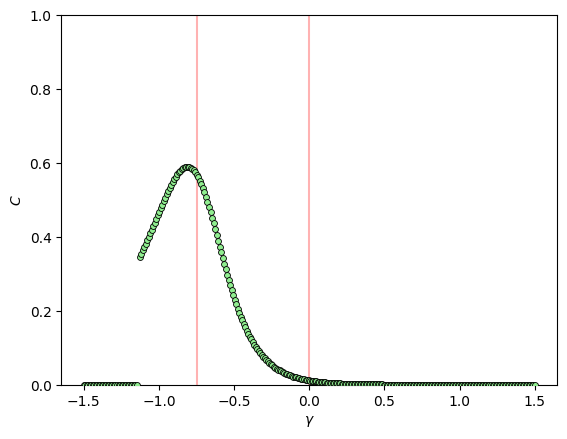

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import json

group_name = "BT"
trial = 55

with open(f"data_ANALYSIS_for_{group_name}_trialNum{trial}.json", "r") as file:
    data = json.load(file)

betas = np.array(data["beta_range"])
gammas = np.array(data["gamma_range"])[0]
u_crit = np.array(data["u_critical"])

N_val = 140
d_heat = 2*np.gradient(u_crit[N_val], gammas)*(u_crit[N_val])**3
print(betas[N_val])
plt.scatter(gammas, d_heat,     s=18,                 # marker size (pt^2)
    marker="o",
    facecolor="lightgreen",    # white fill (Nature common)
    edgecolor="black",
    linewidth=0.6,
    zorder=3)
plt.axvline(x=0, color = "red", alpha =0.3)
plt.axvline(x=-0.75, color = "red", alpha =0.3)
plt.xlabel(r"$\gamma$")
plt.ylabel(r"$C$")
plt.ylim(0,1)
#plt.yscale('log')
#plt.xlim(-0.3,0.3)
#plt.title(r"Heat Capacity vs $\gamma$ for $\mathbb{Z}$" + f"${N}$")
plt.savefig(f'ANALYSIS_for_{group_name}_trialNum{trial}_beta_val{betas[N_val]}.png', format='png', bbox_inches='tight')


#check that u has correct behaviour


(0.0, 4.1)

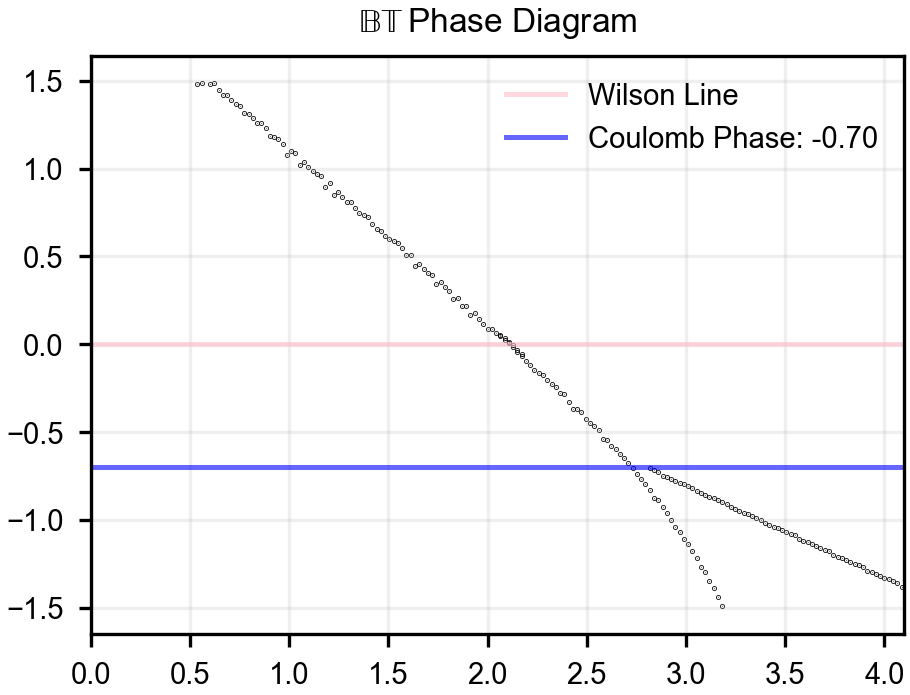

In [149]:
import numpy as np

def phase_diagram(observable, gamma_list, tol_steps = 1, eps = 1e-2):
    
    if np.allclose(observable, 0, rtol=eps):
        return [np.nan, np.nan]
    else:
        left_plane = np.zeros(len(observable))
        index_first_order = np.argmax(observable)
        #print(index_first_order)
        if index_first_order-tol_steps > 1:
            left_plane = observable[0:index_first_order-tol_steps]
            left_gamma_plane = gamma_list[0:index_first_order-tol_steps]
            #print(index_first_order)
            second_order_guess_left = np.argmax(left_plane)
        else:
            left_plane = np.zeros(len(observable))
        if index_first_order < len(observable) - tol_steps - 1:
            right_plane = observable[index_first_order+tol_steps:-1]
            right_gamma_plane = gamma_list[index_first_order+tol_steps:-1]
            
            second_order_guess_right = np.argmax(right_plane)
        else:
            right_plane = np.zeros(len(observable))
        
        #print(right_plane, second_order_guess_right)
        
        if np.allclose(right_plane, 0, rtol = eps):
            if np.allclose(left_plane, 0, rtol = eps):
                return [gamma_list[index_first_order], np.nan]
            if np.isclose(gamma_list[index_first_order], left_gamma_plane[second_order_guess_left], rtol = 0.15):
                return [gamma_list[index_first_order], np.nan]
            else:
                return [gamma_list[index_first_order], left_gamma_plane[second_order_guess_left]]
        if np.isclose(gamma_list[index_first_order], right_gamma_plane[second_order_guess_right], rtol = 0.15):
            return [gamma_list[index_first_order], np.nan]
        else:
            return [gamma_list[index_first_order], right_gamma_plane[second_order_guess_right]]

heat_caps = []

for i,j in enumerate(betas):
    heat_caps.append(2*np.gradient(u_crit[i], gammas)*(u_crit[i])**3)

heat_caps = np.array(heat_caps)

phase_graph = []

for i, val in enumerate(heat_caps):

    phase_graph.append(phase_diagram(val, gammas))
   
   
c1 = [] 
c2 = []

for critical in phase_graph:
    c1.append(critical[0])
    c2.append(critical[1])
    
plt.scatter(betas, c1, marker = ".", color = "black", s=0.15)    
plt.scatter(betas, c2, marker = ".", color = "black", s=0.15)
plt.axhline(y=0, color ="pink", alpha = 0.6, label = "Wilson Line")
plt.axhline(y=-0.7, color = "blue", alpha = 0.6, label = "Coulomb Phase: -0.70")
plt.title(r"$\mathbb{BT}$ Phase Diagram")
plt.legend()
plt.grid(alpha =0.2)
plt.xlim(0,4.1)

In [23]:
test = np.array([1.2,1,1])

print(np.allclose(test, 1, rtol=0.2))

True


/tmp/ipykernel_6038/4202502259.py:24: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(beta_c1, group_size, poly_degree)


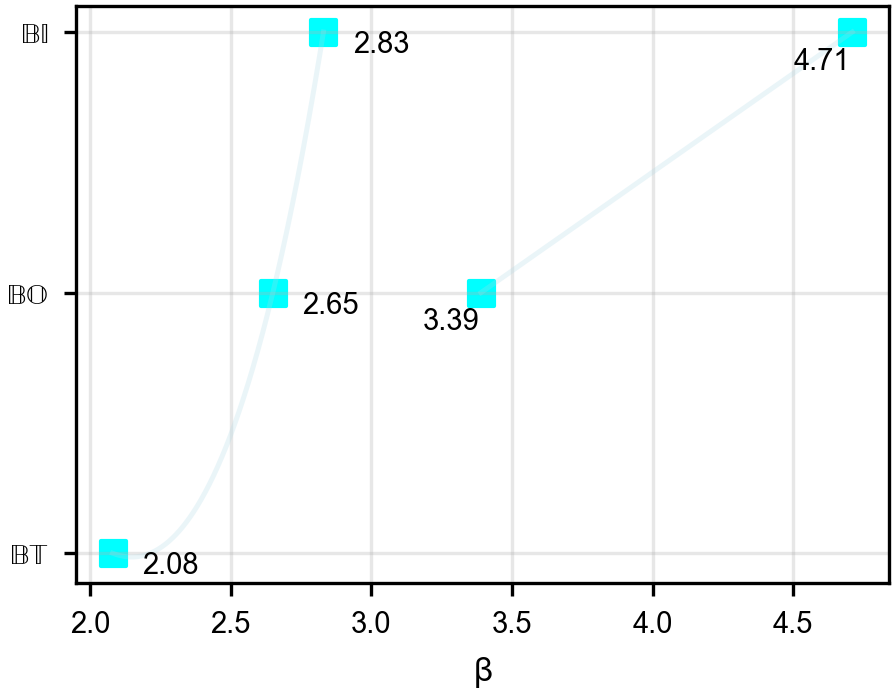

In [110]:
from scipy.optimize import curve_fit

beta_c1 = np.array([2.08, 2.65, 2.83])
beta_c2 = np.array([np.nan, 3.39, 4.71])
beta_c2star = np.array([3.39, 4.71])
group_size = np.array([7,8,9])
group_size2 = np.array([8,9])

plt.scatter(beta_c1, group_size,  color = "cyan", marker = "s")
plt.scatter(beta_c2, group_size, color = "cyan", marker = "s")

for xi, yi in zip(beta_c1, group_size):
    plt.annotate(f"{xi}", (xi, yi), textcoords="offset points", xytext=(7, -5), fontsize = 7)
for xi, yi in zip(beta_c2, group_size):
    plt.annotate(f"{xi}", (xi, yi), textcoords="offset points", xytext=(-14, -9), fontsize = 7)

word_labels = [r"$\mathbb{BT}$",r"$\mathbb{BO}$",r"$\mathbb{BI}$"]    
plt.yticks(group_size, word_labels)
plt.grid(True, alpha = 0.3)
plt.xlabel(r"$\beta$")
poly_degree = 4   # quadratic; change to 1, 3, 4, ...

# Fit coefficients (highest power first)
coeffs = np.polyfit(beta_c1, group_size, poly_degree)

# Polynomial object (clean + reusable)
poly_fit = np.poly1d(coeffs)

x_fit = np.linspace(beta_c1.min(), beta_c1.max(), 300)
y_fit = poly_fit(x_fit)

# Fitted exponential curve
plt.plot(
    x_fit, y_fit,
    color="lightblue",
    linewidth=1.2,
    alpha = 0.25
)

########
# popt, pcov = curve_fit(
#     exp_model,
#     beta_c2star,
#     group_size2,
#     p0=initial_guess
# )

# A_fit, k_fit = popt
# A_err, k_err = np.sqrt(np.diag(pcov))
# x_fit = np.linspace(beta_c2star.min(), beta_c2star.max(), 300)
# y_fit = exp_model(x_fit, A_fit, k_fit)
poly_degree = 1

coeffs = np.polyfit(beta_c2star, group_size2, poly_degree)

# Polynomial object (clean + reusable)
poly_fit = np.poly1d(coeffs)

x_fit = np.linspace(beta_c2star.min(), beta_c2star.max(), 300)
y_fit = poly_fit(x_fit)

plt.plot(
    x_fit, y_fit,
    color="lightblue",
    linewidth=1.2,
    alpha = 0.25
)

plt.savefig('phase_plot_BN.svg', format='svg', bbox_inches='tight')